# Ch 17 Speeding Up Transformers

## Faster Inference Time Decoding

- For any model with a decoder component, it generates 1 token at time, sequentially. This is basically the same issue that RNNs had, but theres ways to get around this

### KV Caching

Each attn head in MHA layer computes scaled dot product attn: 
- Attention(Q,K,V) = softmax $(QK^T/ \sqrt{d_k})V$
- Remember d_k is a key dimensionaity, and in self-attn the QKV matrices are projections of the input sequence
- Row i has the i'th input token rep, and since MHA is masked, the token representation only influenced by tokens 1 to i, therefore adding a token just adds a row
- So just cache the matrices and only recompute the new row!
- Only cache KV: you dont need all of Q, since you only care about the last token output, so you only need the last row of Q

How does this work?
- Call decoder -> every KV matrix in every attn head in every MHA layer get saved to a cache ("prefill stage") : this step is dont normally (no shrunk Q)
- Each matrix has i rows, one per token, decoder outputs next token preds for 1 to i, you only care about i+1
- When you want the next token, just input token i+1, the first i tokens are already saved, Q,K,V projections give vectors [1 x d_k] for the new 1 token

**KV Cache memory management** is hard - changing size, variable length sequences, etc. PagedAttention in vLLM uses memory pages for efficient batching

Most HF transformers models support KV caching by default. The default cache is `transformers.DynamicCache`, but if you are using special attention like sparse attention other caches might be better

### Speculative Decoding

Idea: most tokens that an LLM generates are easy to predict. Example: "Your Python code is good, but there are syntax errors on lines 3 and 7." The only difficult words in this sentence would be the exact line numbers and Python, given the past tokens.

Use a fast model to predict the easy tokens - but which tokens are easy? You cant tell ahead of time.

Google researchers proposed this:
- For every generation step, pass the context containing tokens c_1 to c_t to the draft (small) model, and have it generate a sequence of n (d_t+1, d_t+n) more tokens.
    - You use KV caching and the small model and the generation is many times faster than the big model
- Then give the entire context + draft to the large (target) model [with kv caching, you only need to pass c_t, d_t+1, ...]
    - The target model processes n tokens in parallel rather than sequentially generating them
- For every input token, target outputs tokens o_1, o_t+n, where o_i = predicted next token (assuming each previous token is "correct")
- Now check the draft quality: if $d_i = o_{i-1}$, $\forall i \in [t+1, t+n]$, the draft was correct!
    - You can also append o_t+n, since it wasnt checked in the draft but is the target models next token prediction
- If the draft tokens are wrong? If the first draft token is wrong, the rest are useless, but if the draft got the first 3 right, you can keep the first 3+1 (target models prediction from the quality check)
    - Worst case scenario you still get 1 token from the target model, and all it cost you was a quick pass from the drafter

This is great but what about temperature and token probabilities? Models output logits for each next token, not one-hot vectors.
- You want your speculative decoding token distribution to be identical to the target model distribution

This is possible with **speculative sampling**, proved mathematicaly to yield identical token distributions!
- When generating draft token at idx i, draft model computes probability distribution $q_i(x)$ over the next possible token values (x), where the random choice = $d_i$
- The whole sequences goes through the target model, which gives probability distribution $p_i(x)$ over all possible next tokens -> DONT PICK AN OUTPUT YET
- For each draft tkn $d_i$, accept if $q_i(d_i) <= p_i(d_i)$, else, only accept with prob $q_i(d_i) / p_i(d_i)$, otherwise reject.
- If a draft is rejected, immediately stop, reject all the rest, sample the next token from the target model using an adjusted distrbution:
    - $p'_i(x) = max(0, p_i(x) - q_i(x)) / s_i$, with s_i as some constant of normalization
    - the purpose of this is to not oversample tokens the draft model can do


Draft length sequences: if too short, no speedup, if too long, most tokens will get rejected and slow you down
- Just tune this, mess around with it until you find one that works OR
- *Dynamic speculative decoding*: keep generating draft tokens until the drafter confidence falls beyond some threshold (this is the default)

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
# target_model = AutoModelForCausalLM.from_pretrained("facebook/opt-350m",device_map="auto")
# draft_model = AutoModelForCausalLM.from_pretrained("facebook/opt-125m",device_map="auto")
# tokenizer = AutoTokenizer.from_pretrained("facebook/opt-350m")
# prompt = "Once upon a time there lived"
# inputs = tokenizer(prompt, return_tensors="pt").to(target_model.device)
# outputs = target_model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=1, assistant_model=draft_model)
# result = tokenizer.decode(outputs[0], skip_special_tokens=True)

/home/will/Desktop/ML_notes/MLNotes/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Note: Practically I have seen this implemented with the Qwen3.6 27B model using an 0.8B drafter - drafter usually 10-20x smaller

MUST have the same tokenizer for the two models, otherwise your drafter and target are literally speaking different languages

Also, different tasks have differing levels of success:
- Summarization will speed up massively since its "easy" for llms
- Generating complex code in obscure programming languages while also writing comments in grammatically correct classical Latin will be very difficult for a drafter to do


### Main Approaches to Parallelize Decoding

**Draft and Verify**: speculative decoding and variants

**Decompose and fill**: break a problem into tasks, then do each task in parallel ("Generate 3 jokes, find which element in a list satisfies X, etc")

**Multiple token prediction**: Fine tune the LLM to predict >1 token at a time, which it can then check itself.
- Implement this by adding a <lookahead> token in training which tells the model theres multiple tokens here to predict

**One shot generation**: A one shot model produces the entire output in 1 parallel step - very fast, very prone to errors since you arent sequentially going token by token

**Masked generation**: Start with a fully masked sequence, eventually predict some words, and at each step, predict new and refine old tokens

**Edit based refinement**: use an editor model to edit the drafter output

## MHA Speed-ups

Multi Head Attention is the most expensive operation in LLMs, and speeding it up is very helpful for efficiency

softmax $(QK^T/ \sqrt{d_k})V$ -> expensive part is $QK^T$ -> this outputs an Lq x Lk matrix (length of query x length of key)
- For self attn, Lk = Lq since its the same sequence, so for very long sequences the matrix grows into a massive square matrix

### Sparse Attention

For normal masked MHA, every query looks at every key up to its position. What if we changed that?

#### Sparse Transformers
Decoder only, 2019, OpenAI
- Half the attn heads only look at the last n (like n=256) local tokens, while the other half only attends to every n tokens globally. 
- N is called the stride, usually pick n = root(max_seq_len)

Strided sparse attention - both local and global masks slide smoothly with the query tokens - works good for imgs/periodic data

Fixed sparse attention - query split into blocks of n token length, local mask is the querys block, global mask is the last key token of every block. Better for text

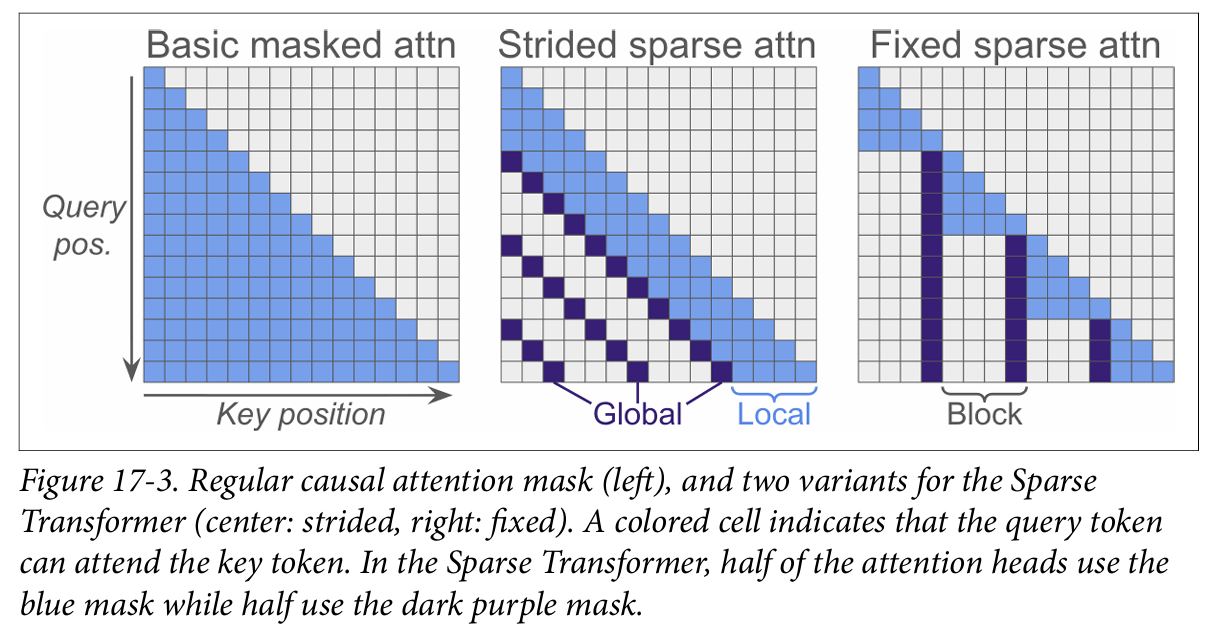

Each query only sees n_local_tokens and position_idx / n_global_tokens versus position_idx tokens - much better efficiency

But now information has to go to a global token to get somewhere, so there are bottleneck issues or anything that needs very specific details to be known everywhere

#### Longformer
Encoder-only, 2020

- Attn masks now look at past and future tokens, symmetric about main diagonal of matrix
- Uses a standard sliding window of local attention, centered on the query token index, usually about a 512 token window (meant to be used on LONG documents)

Important: uses a fixed number of global tokens
- For classification, uses [CLS] as only global token which attends to / is attended to by every token
- For question answering, make every question token global

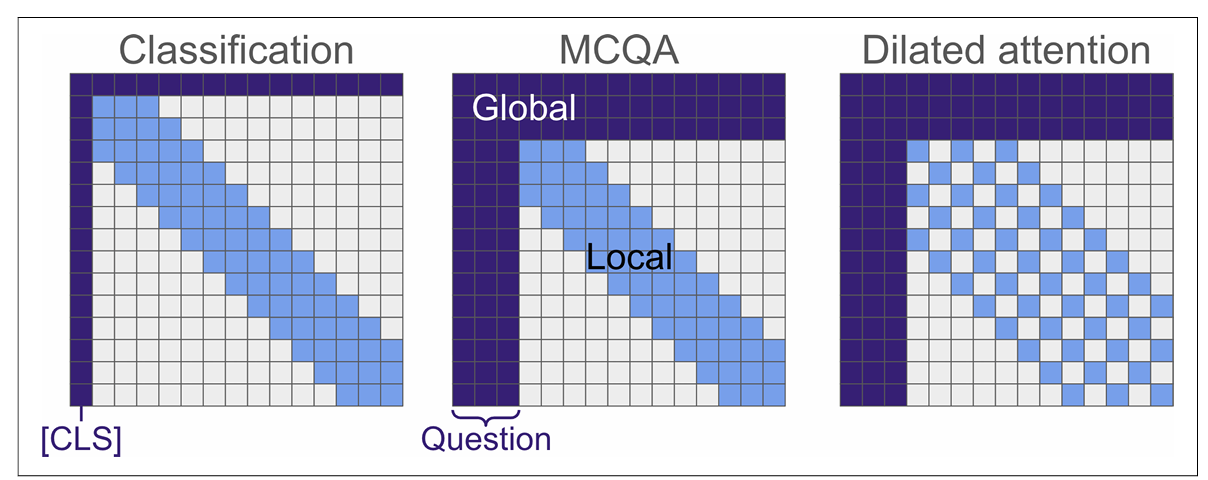

Another idea in the original paper: use short windows at low layers, long windows at high layers -> low levels focus on small patterns, dont need massive attention windows

Also proposed dilated windows like WaveNet to expand windows even more

#### BigBird
Google, 2020 -> like the longformer - dilation + random attention

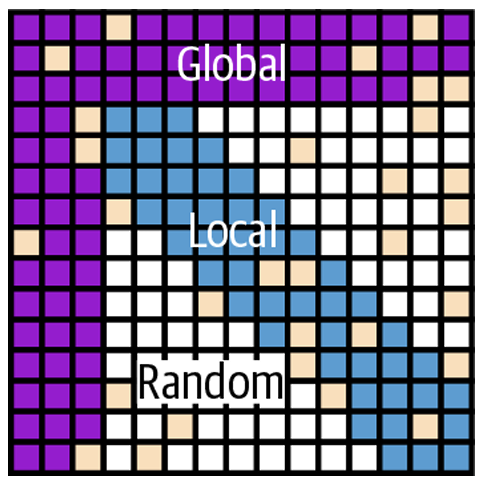

Random Attention offers good theoretical guarantees: scales to long sequences linearly, and just as expressive as original architecture

Paper also showed BigBird can execute any function (as long as you feed itself its outputs). However, it needs more layers, because information needs to travel through a lot of random tokens to get everywhere

Every attn head uses a different random mask, and the random mask is constant

Generally better than the LongFormer on long context


#### Routing Transformer
Google, 2020

Previous mechanisms chose attentions based on positions, this one groups Q and K tokens into clusters, then computes scaled dot-product attn for each cluster separately. 

Clustering is based on similarity scores btwn tokens, but tokens carry positional encoding info, so more similar tokens are already more likely to be close

Routing Transformer does mini-batch k-means, with each attn head having k centroids [each centroid is a learned vector]

Each centroid is updated with an EMA of the closest s tokens during training

Use k close to root(max_seq_len) - but routing transformers are hard to implement, not as popular


### Approximate Attention

You can either change the formula itself or compress the input values.

- Pyramid Vision Transformer in ch16 uses spatial reduction attention - compressed KV in spatial dims, makes memory usage O(Lq* Lk / r^2) wheras normal attn is just O(Lq*Lk)
- Perceiver's cross-attn turns input sequence into constant latent sequence - O($l L_k$) where l is constant

#### Reformer - LSH approx attn
LSH: Locality-sensitive hashing attention - O($L_q \log (L_k)$) vs O($L_qL_k$) - slightly degrades accuracy

For regular attn, QK^T inside softmax computationally expensive. But softmax mostly determined by a few dominant terms, or the QK pairs with largest dot product

So what if we have a separate algorithm to identify the most similar QK pairs and use that, and then calculate QK^T for only the similar pairs

Hash functions usually pseudorandom, so LSH hashes in a way that similar vectors have similar outputs

Cross Polytope LSH / Angular LSH : 
- Desired n_clusters = k. We create a list of L random vectors by sampling $r_1$ to $r_{k/2}$, indep from normal dist
- Append opposite vectors $-r_1$ to $-r_{k/2}$ to the list. K total vectors
- For each vector you want to hash, find vector in L most aligned with it, and use its index in L as the hash for v.

In [ ]:
# in torch:
import torch
import torch.nn as nn
import torch.nn.functional as F

def angular_lsh(vectors, k):
    R = torch.randn(vectors.size(-1), k//2, device=vectors.device) # generate r1 - r{k/2}
    norm_vectors = F.normalize(vectors, p=2.0, dim=1) # normalize
    V_proj = norm_vectors@R # gets (roughly) similarity score for each
    V_concat = torch.cat([V_proj, -V_proj], dim=1) # concatenate horizontally and get opposite scores for free
    return torch.argmax(V_concat, dim=1) # return the highest similarity idx per row

You could cluster all query and key tokens together, but this is too approx and doesn't yield good results

But theres an easy fix: run multiple angular LSH rounds, then just calculate attention for all key tokens the query token was clustered with at least once

The Reformer also added:
- Reversible residual layers (ch12 - basically make it possible to recompute activations instead of store them in memory)
- Chunked feedforward layers 
- Axial pos encoding - replace 1 large positional embed matrix with 2 small ones
- Shared Q and K projections (this hurts accuracy)

#### Linformer: Low-rank approx attn
Consider Attention(Q,K,V) = softmax(QK^T / root(dk))*V = PV. P = "context mapping matrix" and its an Lq x Lk matrix - and generally very close to a low-rank matrix, generally close to rank r = log(Lq) for self-attn.

So: shorten keys and vals using two linear projections E and F, learned during training. This reduces the sequences themselves not the dimensionality of each token.

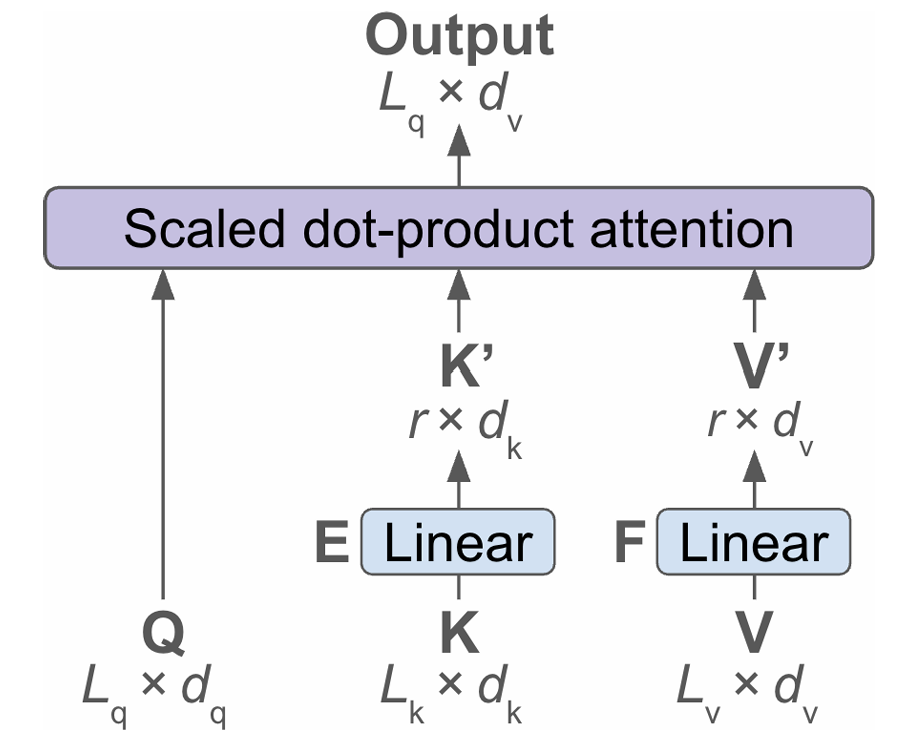

So r is a compressed sequence length. Note you have to make E and F large enough for the max seq length, and truncate to match the number of cols.

Meta researchers also tried:
- Sharing E and F across all attn heads in a layer
- Use same projection G to compress K and V (shared across a layer)
- Use G across all attn heads and layers

Scales well, accuracy isn't too bad

#### Performer: Kernel-based approx attn
Uses an approximation of dot product attn with a kernel trick

Remember: softmax computes the exponential of every term in the input, and divides each row by its sum, so it adds to 1. softmax(M) = $D^{-1}A$, where A=exp(M) and D is some diagonal matrix where each val in the main diagonal corresponds to the sum of each row in A

Assuming Q,K already scaled, performer uses $\phi$ function to approx attn: Attention(Q,K,V) = $D^{-1}\phi (Q) \phi (K)^T V$ This replaces the big QK^T with a bunch of smaller matmuls.

We use the kernel trick:
- A kernel is some function K(x,y) that calculates dot product $f(x)\cdot f(y)$
- But in this case K(x,y) = exp(QK^T) which is massive
- So instead we use Attention(Q,K,V) = $D^{-1}\phi (Q) \phi (K)^T V$ which is smaller, basically calculating f to avoid using K

Ok.. but what is $\phi$? It's called **Fast Attention Via positive Orthogonal Random features** (FAVOR+)

$\phi (X) = \dfrac{h(X)}{\sqrt m} [f_1(XW);...;f_l(XW)]$

- phi(x) maps X from a d-dimensional space to a l*m dimensional space (l=n_functions, m is a hyperparameter)
- h(X) is any function that returns a scaling factor for each row of X
- f_1 to f_l are any itemwise real functions (exp)
- W is any nontrainable d x m matrix - either deterministic or random
- [..;...;...] means horizontal concatenation

The performer authors chose this approx:
- h(X) = exp($(-1/2)||x_i||^2$) for each for x_i in X
- l = 1
- f1(x) = exp(x)
- W is random
- m is a hyperparam, higher = more accurate and more computation

See book for pytorch implementation - somewhat complex


### Sharing Projections across Attn Heads

MHA takes in Q,K,V applies lin transform, then splits the results across attn heads evenly. For example. h=8 attn heads, d=512 input dim, then you get 8 projected q, k, and v's, all 64-dim. But you need 3 d x d projection matrices... which is a lot of numbers. So how can we share these projections and speed things up?

#### Multi-Query attn (MQA)
Use the same K and V projection across all heads, but a different Q. Reduces flexibility but makes the model smaller.

#### Grouped Query Attention (GQA)
Split attn heads into groups, and each group shares K and V projections. MQA is just GQA with 1 group.

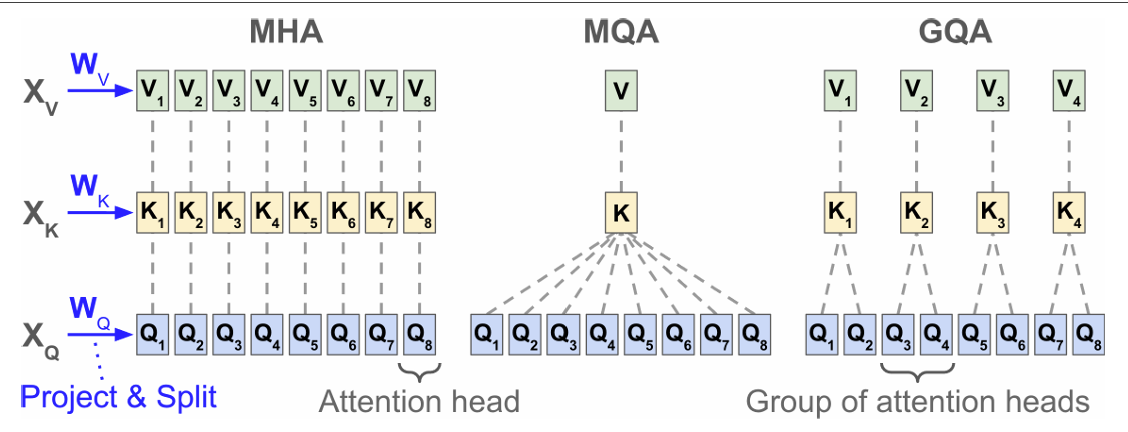

In PyTorch, F.scaled_dot_product_attention() has an `enable_gqa=True` param that can be used to easily implement this. 

#### Multi-head latent attention (MLA)
Developed by DeepSeek in 2024, seems to do better than GQA. Reduces cache roughly as much as MQA but without reducing quality - actually improving quality.

MLA primarily works by compressing the d-dimension k and v values into a smaller latent space, using a trainable projection $W_{KV}$

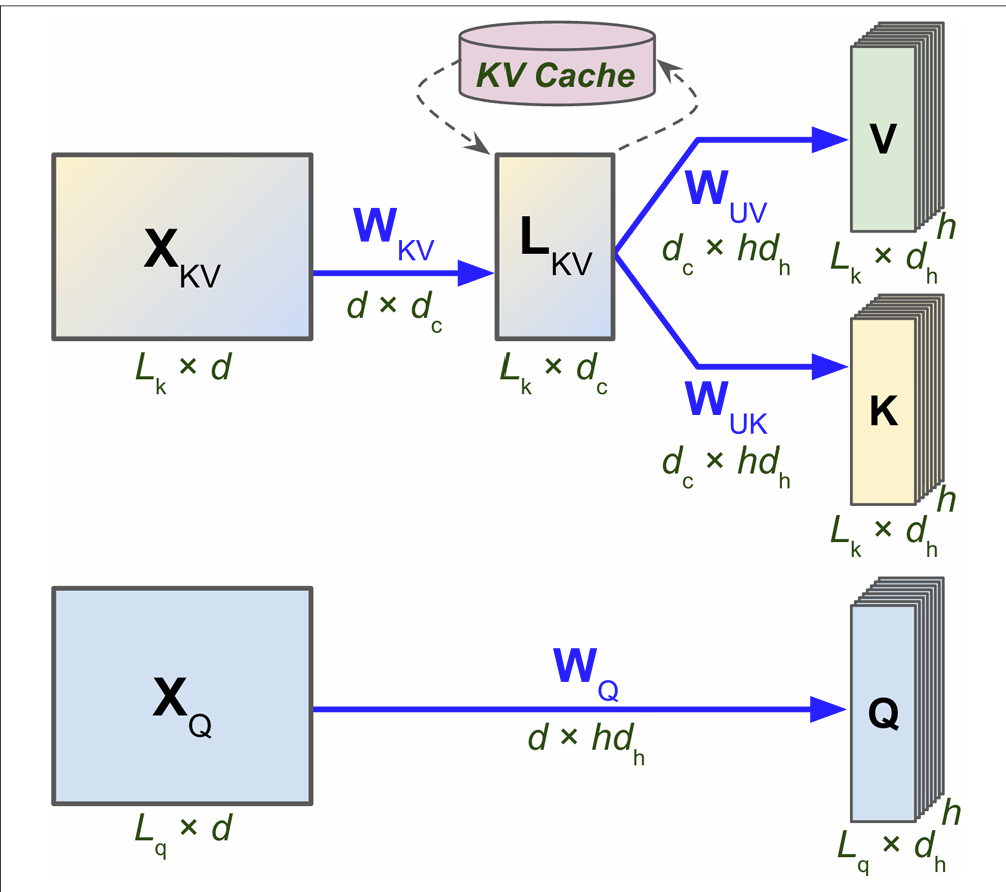



**KV cache size for MHA, MQA, GQA, and MLA**

| Architecture | KV Cache Size Equation | Example |
|---|---|---|
| MHA | p × nL × nt × dh × h × 2 | 3,750 MB |
| MQA | p × nL × nt × dh × 2 | 29 MB |
| GQA | p × nL × nt × dh × g × 2 | 469 MB |
| MLA | p × nL × nt × dc | 59 MB |

In this table:

- p is the floating point precision, in bytes (e.g., 2).
- nL is the number of MHA layers in the model (e.g., 60).
- nt is the total number of tokens stored in the cache (e.g., 1,000).
- dh is the attention head dimensionality (e.g., 128).
- h is the number of attention heads (e.g., 128).
- g is the number of groups in GQA (e.g., 16).
- dc is the dimensionality of the latent space (e.g., 512).

So MLA is almost as good as MQA's efficiency, but much better accuracy
- Uses projected K's and V's for each attn head, so more flexibility
- Smaller matrices = faster training

### FlashAttention

A GPU optimization for scaled dot product attn, going at 2-4x speed

First, need to know how GPU memory works. Its split into different types, fastest to slowest:

**Registers**
- 1 gpu has multiple clusters of processers, running parallel. One cluster is a Streaming Multiprocessor (SM). Each SM has some number of 32bit registers, and each thread in a SM has access to some number of registers. Registers can be accessed in 1 clock cycle and are therefore the fastest kind of memory.

**L1 Cache / Shared Memory**
- Each SM has some memory shared across all threads. Can be used to store data chunks/communicate btwn threads. L1 cache automatically caches frequently accessed data

**L2 Cache**
- Lives on-chip, shared across all SMs but is slower, has more capacity
- Keeps model weights sometimes

**Global Memory**
- All previous memory lives in SRAM (static), which is fast and expensive
- Global memory (HBM/high bandwith memory) lives in DRAM (dynamic), which is slower and cheaper
- This is where models are stored and data batches go


To minimize time, need to minimize transfers btwn global memory and SRAM. Thus, tiled matrix multiplication:
- Chop two matrices to be multiplied into tiles, which are just small matrices that can fit in SRAM
- Multiply the tiles up and add results to compute output

You can also speed up softmax:
- Instead of doing a lot of fetches for the matrices and itemwise division and keeping track of a running softmax total,
- Fuse exponential and row sum operations: iterate over each row of QK^T and keep a running track of exp(M_ij) per row, then iterate over QK^T again and compute exp(M_ij) / rowsum. **Online softmax**

FlashAttn also avoids overflow by subtracting the max row value before exponentiating (safe softmax)

FlashAttention-2: optimizes GPU thread parallelism

FlashAttention-3: exploits new nvidia tech, asynchronous execution, low precision of blackwell chips

## MoE

MoE transformers dont specialize like humans - not a coding expert, medical expert, etc. Its very low-level

### The MoE layer
Idea: replace the FFN in some transformer blocks with an MOE layer, composed of multiple FFNs called experts, +a router network that decides which experts process each input token

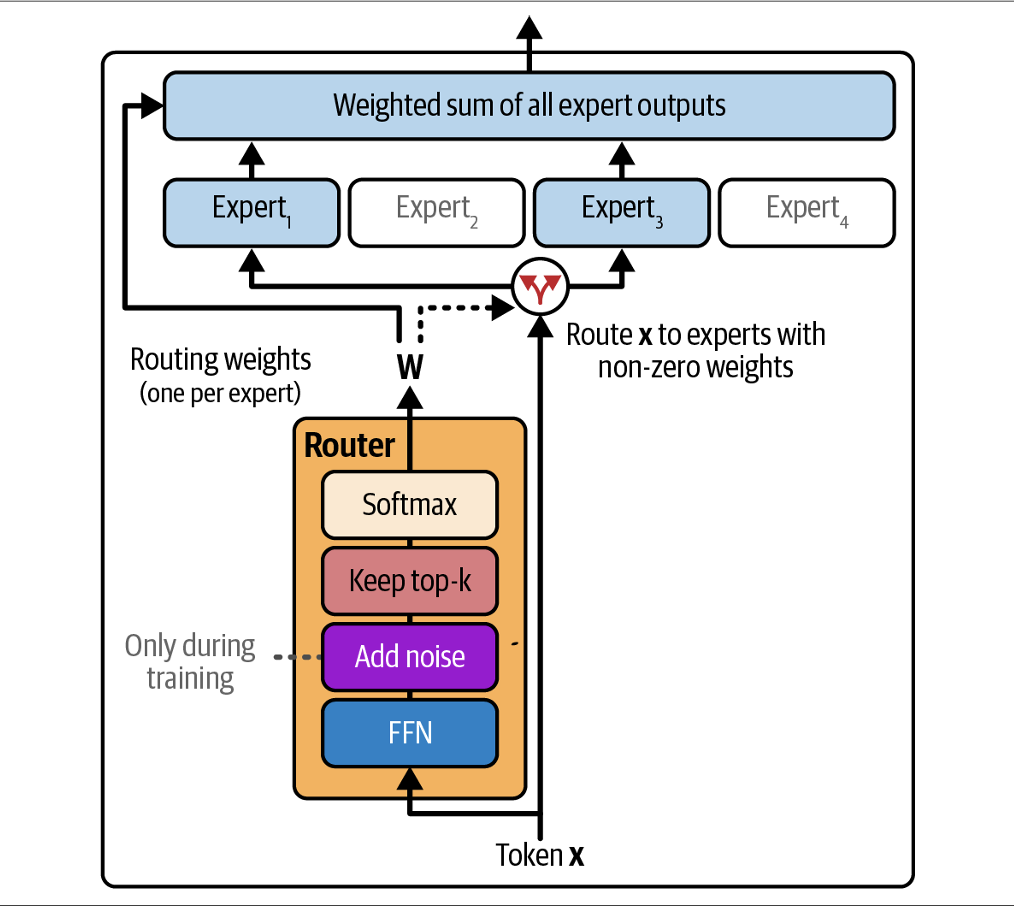

- Router network outputs a vector containing 1 weight per expert
- Find top-k weights, route input x to k experts
- Compute weighted sum of expert outputs, where each output * routing weight

You can also do this recursively (an expert becomes an MOE layer itself)

### MoE Benefits
- Can make the overall model much larger and keep the same speed, since each input uses a subset of weights
- Most experts needed at the same time for long sequences

### MoE Challenges

#### Load Balancing
- Need the average number of tokens shown to each expert to be the same during training otherwise you undertrain some experts
- Solution: load-balancing loss, which is per MoE layer, and added to overall loss
    - Adds Gaussian noise in the original architecture, but more recently they just use a simple loss fn:

Auxiliary load-balancing loss:
$L_{LB} = \alpha N \sum_{i=1}^{N} f_i Q_i$
- alpha is a hyperparam, determines how strongly model favors equal balance
- N = total number of experts
- f_i is % tokens in current batch given to i'th expert
- Q_i = mean routing weight given to i'th expert

This pushes every f_i and Q_i to 1/N

Other techniques
- Random Routing: if k=2, pick top expert and the second one randomly, with p(selected)=routing weight
- Expert capacity: Each expert only can see a max of C tokens per batch (a hyperparameter). If a token gets routed to a max-capacity expert, the expert is ignored and its tokens get re-routed. If all candidate experts "full" - MoE layer outputs zero, skip connection allows token to keep traversing network

#### Reducing expert overlap
- You could use a more powerful router network, but thats expensive
- Or: shared experts, used for every token, which encourage the other experts to specialize
    - DeepSeek used 1 shared expert, 256 specialists, 8 active 

#### Engineering challenges
- MoE transformers are huge and may need cross-gpu sharding
- If a model is sharded across servers, you need to detect node failures
- Tokens must be routed dynamically and batched to increase GPU utilization
- Overloaded or hot experts slow down the entire model

## Fast Training and Tuning

Example: 7B parameter model

- Model weights: at 16-bits, 14Gb of memory for the weights alone, and if you are using mixed-precision training you need a 32-bit copy of the weights (+28gb)
- Activations: during training, have to save all activations of the forward pass, since you need them for the backward pass. The exact # depends on batch size, sequence length, precision, etc., but roughly ~40GB
- Gradients: 1 per parameter. Training 7B parameters at 16-bits = 14Gb.
- Optimizer states: Need more data for each parameter: for Adam, 2 running avgs, usually stored in 32-bit precision, thus 56gb.

All in all, 152 GB for training a 7B parameter model in mixed precision.

### PEFT: Parameter Efficient Fine Tuning

You can speed up fine-tuning by reducing the number of trainable parameters

Most popular PEFT technique is to use adapters: freeze the weights of the large model, insert smaller trainer adapters, and train the adapters.

Types of adapters
- prefix adapters: learnable key-value prefixes
- Low-Rank Adaption (LoRA)

**LoRA**

First, freeze the model, choose the weights you want to fine tune
- Generally, adapt at least Q and V projections in every MHA layer
- Might also want to adapt Key and output projections, and weights in FFN

Each XW matrix mult (W being a weight you want to fine tune) is replaced with XW+XBA, where A and B are new adapter matrices. If W is a $ d * k $ matrix, B = d*r, A = r *k

r is some hyperparameter that controls the size of the LoRA adapters

Overall, instead of tuning d*k, you tune r * (d+k).

And even though BA is a d*k matrix, you never compute it since XB = b * r (b=batch), and XBA = (b * r) * (r * k) = b * k